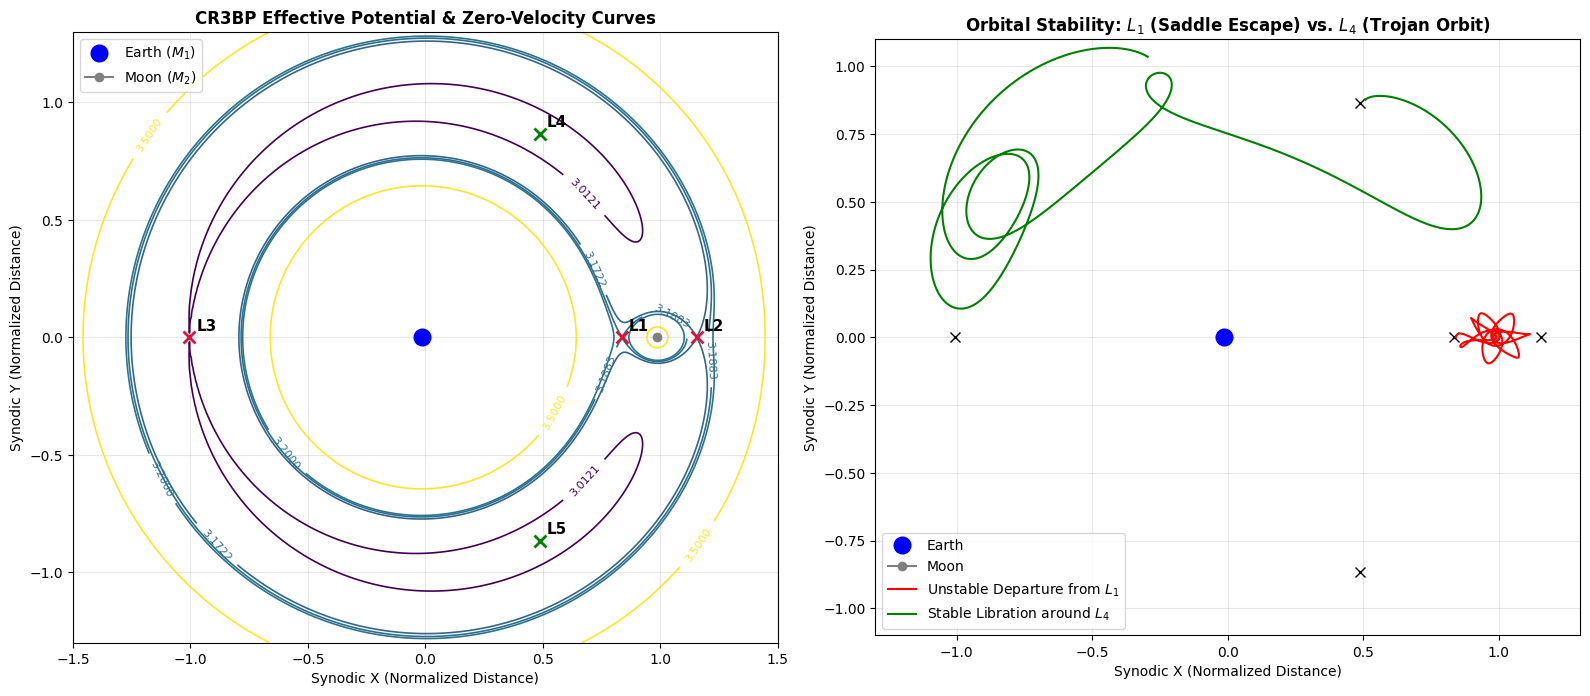

Calculated Lagrange Coordinates (Synodic Frame):
  L1: (0.836915, 0.000000) | Jacobi Constant C = 3.188341
  L2: (1.155682, 0.000000) | Jacobi Constant C = 3.172160
  L3: (-1.005063, 0.000000) | Jacobi Constant C = 3.012147
  L4: (0.487849, 0.866025) | Jacobi Constant C = 2.987997
  L5: (0.487849, -0.866025) | Jacobi Constant C = 2.987997


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# -------------------------------------------------------------
# 1. Physical Setup: Earth-Moon System Normalized Parameters
# -------------------------------------------------------------
# Mass ratio for Earth-Moon: mu = M_moon / (M_earth + M_moon)
mu = 0.0121505856

# Primary body positions in rotating synodic frame
x1, y1 = -mu, 0.0          # Earth (Primary 1)
x2, y2 = 1.0 - mu, 0.0      # Moon (Primary 2)

def effective_potential(x, y):
    r1 = np.sqrt((x + mu)**2 + y**2)
    r2 = np.sqrt((x - 1.0 + mu)**2 + y**2)
    return 0.5 * (x**2 + y**2) + (1.0 - mu)/r1 + mu/r2

def d_omega_dx(x, y=0.0):
    r1 = np.abs(x + mu)
    r2 = np.abs(x - 1.0 + mu)
    return x - (1.0 - mu)*(x + mu)/(r1**3) - mu*(x - 1.0 + mu)/(r2**3)

# -------------------------------------------------------------
# 2. Solving Collinear Lagrange Points (L1, L2, L3)
# -------------------------------------------------------------
# Roots along the y = 0 axis
sol_L1 = root_scalar(d_omega_dx, bracket=[x1 + 0.05, x2 - 0.01], method='brentq')
sol_L2 = root_scalar(d_omega_dx, bracket=[x2 + 0.01, 1.5], method='brentq')
sol_L3 = root_scalar(d_omega_dx, bracket=[-1.5, x1 - 0.05], method='brentq')

L1 = np.array([sol_L1.root, 0.0])
L2 = np.array([sol_L2.root, 0.0])
L3 = np.array([sol_L3.root, 0.0])

# Triangular Lagrange Points (Equilateral geometry: r1 = r2 = 1)
L4 = np.array([0.5 - mu,  np.sqrt(3)/2])
L5 = np.array([0.5 - mu, -np.sqrt(3)/2])

lagrange_points = {'L1': L1, 'L2': L2, 'L3': L3, 'L4': L4, 'L5': L5}

# -------------------------------------------------------------
# 3. Numerical Integrator in the Rotating Frame
# -------------------------------------------------------------
def equations_of_motion(state):
    x, y, vx, vy = state
    r1 = np.sqrt((x + mu)**2 + y**2) + 1e-4
    r2 = np.sqrt((x - 1.0 + mu)**2 + y**2) + 1e-4

    # Gravitational + Centrifugal gradients
    omega_x = x - (1.0 - mu)*(x + mu)/(r1**3) - mu*(x - 1.0 + mu)/(r2**3)
    omega_y = y - (1.0 - mu)*y/(r1**3) - mu*y/(r2**3)

    # Include Coriolis acceleration terms
    ax = 2.0 * vy + omega_x
    ay = -2.0 * vx + omega_y
    return np.array([vx, vy, ax, ay])

# RK4 integrator (standard for rotating frames with velocity coupling)
def integrate_cr3bp(state0, t_span, dt=0.001):
    num_steps = int((t_span[1] - t_span[0]) / dt)
    traj = np.zeros((num_steps, 4))
    state = state0.copy()

    for i in range(num_steps):
        traj[i] = state
        k1 = equations_of_motion(state)
        k2 = equations_of_motion(state + 0.5 * dt * k1)
        k3 = equations_of_motion(state + 0.5 * dt * k2)
        k4 = equations_of_motion(state + dt * k3)
        state += (dt / 6.0) * (k1 + 2.0*k2 + 2.0*k3 + k4)

    return traj

# Probe 1: Halo-like perturbation near L1 (saddle instability)
state_L1 = np.array([L1[0] + 0.005, 0.0, 0.0, 0.05])
traj_L1 = integrate_cr3bp(state_L1, (0, 8.0), dt=0.0005)

# Probe 2: Stable libration orbit circulating L4
state_L4 = np.array([L4[0] + 0.02, L4[1] + 0.01, 0.0, 0.0])
traj_L4 = integrate_cr3bp(state_L4, (0, 30.0), dt=0.002)

# -------------------------------------------------------------
# 4. Plotting Zero-Velocity Curves & Trajectories
# -------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Grid for Effective Potential Contours (Zero-Velocity Surfaces)
X = np.linspace(-1.5, 1.5, 400)
Y = np.linspace(-1.3, 1.3, 400)
XX, YY = np.meshgrid(X, Y)
ZZ = effective_potential(XX, YY)

# Subplot 1: Hill's Regions and Lagrange Points
C_L1 = 2 * effective_potential(L1[0], L1[1])
C_L2 = 2 * effective_potential(L2[0], L2[1])
C_L3 = 2 * effective_potential(L3[0], L3[1])

contours = ax1.contour(XX, YY, 2*ZZ, levels=[C_L3, C_L2, C_L1, 3.2, 3.5], cmap='viridis', linewidths=1.2)
ax1.clabel(contours, inline=True, fontsize=8)

# Plot Primaries & Lagrange points
ax1.plot(x1, y1, 'bo', markersize=12, label="Earth ($M_1$)")
ax1.plot(x2, y2, 'gray', marker='o', markersize=6, label="Moon ($M_2$)")

colors = {'L1': 'crimson', 'L2': 'crimson', 'L3': 'crimson', 'L4': 'green', 'L5': 'green'}
for name, pt in lagrange_points.items():
    ax1.plot(pt[0], pt[1], marker='x', markersize=9, markeredgewidth=2, color=colors[name])
    ax1.text(pt[0] + 0.03, pt[1] + 0.03, name, fontweight='bold', fontsize=11)

ax1.set_title("CR3BP Effective Potential & Zero-Velocity Curves", fontweight='bold')
ax1.set_xlabel("Synodic X (Normalized Distance)")
ax1.set_ylabel("Synodic Y (Normalized Distance)")
ax1.set_aspect('equal')
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Subplot 2: Trajectory Stability Breakdown (L1 Unstable vs. L4 Stable)
ax2.plot(x1, y1, 'bo', markersize=12, label="Earth")
ax2.plot(x2, y2, 'gray', marker='o', markersize=6, label="Moon")
for name, pt in lagrange_points.items():
    ax2.plot(pt[0], pt[1], 'kx', markersize=7)

ax2.plot(traj_L1[:, 0], traj_L1[:, 1], 'r-', linewidth=1.5, label="Unstable Departure from $L_1$")
ax2.plot(traj_L4[:, 0], traj_L4[:, 1], 'g-', linewidth=1.5, label="Stable Libration around $L_4$")

ax2.set_title("Orbital Stability: $L_1$ (Saddle Escape) vs. $L_4$ (Trojan Orbit)", fontweight='bold')
ax2.set_xlabel("Synodic X (Normalized Distance)")
ax2.set_ylabel("Synodic Y (Normalized Distance)")
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-1.1, 1.1)
ax2.set_aspect('equal')
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Calculated Lagrange Coordinates (Synodic Frame):")
for name, pt in lagrange_points.items():
    print(f"  {name}: ({pt[0]:.6f}, {pt[1]:.6f}) | Jacobi Constant C = {2*effective_potential(pt[0], pt[1]):.6f}")